<a href="https://colab.research.google.com/github/fotomain/aigoogle3-results/blob/main/AiGoogle3_statistics1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
### YOUR CODE HERE ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

In [6]:
# education_districtwise.csv

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
file_path = '/content/drive/MyDrive/py_csv/education_districtwise.csv'
d = pd.read_csv(file_path)

In [8]:
d.head()

,DISTNAME,STATNAME,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,OVERALL_LI
0,DISTRICT32,STATE1,13,391,104,875564.0,66.92
1,DISTRICT649,STATE1,18,678,144,1015503.0,66.93
2,DISTRICT229,STATE1,8,94,65,1269751.0,71.21
3,DISTRICT259,STATE1,13,523,104,735753.0,57.98
4,DISTRICT486,STATE1,8,359,64,570060.0,65.00


<Axes: >

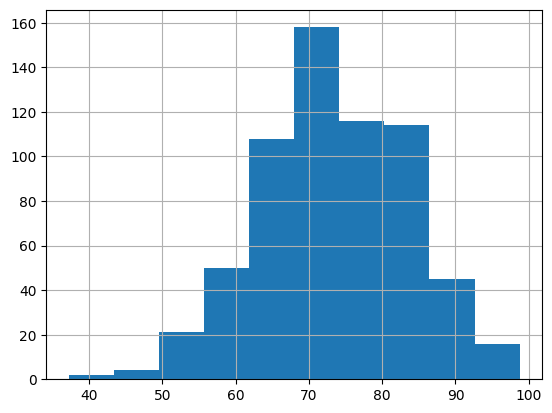

In [9]:
d['OVERALL_LI'].hist()


In [10]:
mean_overall_li = d['OVERALL_LI'].mean()
print("Mean of OVERALL_LI:", mean_overall_li)

Mean of OVERALL_LI: 73.39518927444796


In [11]:
std_overall_li = round(d['OVERALL_LI'].std(),2)
print("Standard deviation of OVERALL_LI:", std_overall_li)

var_overall_li = round(d['OVERALL_LI'].var(),2)
print("Variance of OVERALL_LI:", var_overall_li)

Standard deviation of OVERALL_LI: 10.1
Variance of OVERALL_LI: 101.98


In [12]:
  #inside["OVERALL_LI"].hist()

In [13]:
n_all = len(d)
for sigma_n in [1,2,3]:
  upper_bound = round(mean_overall_li + sigma_n * std_overall_li,0)
  lower_bound = round(mean_overall_li - sigma_n * std_overall_li,0)

  inside = d[
      (d["OVERALL_LI"] >= lower_bound) &
      (d["OVERALL_LI"] <= upper_bound)
  ].copy()

  n_inside = len(inside)
  percentage = n_inside/n_all*100
  print("███████████ sigma interval",sigma_n*2)
  print("n_all",n_all)
  print("std_overall_li",std_overall_li)
  print("n_inside",n_inside)
  print("percentage",round(percentage,0))

███████████ sigma interval 2
n_all 680
std_overall_li 10.1
n_inside 415
percentage 61.0
███████████ sigma interval 4
n_all 680
std_overall_li 10.1
n_inside 606
percentage 89.0
███████████ sigma interval 6
n_all 680
std_overall_li 10.1
n_inside 632
percentage 93.0


In [14]:
d['Z_SCORE'] = stats.zscore(d['OVERALL_LI'],nan_policy='omit')


In [15]:
d.head()

,DISTNAME,STATNAME,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,OVERALL_LI,Z_SCORE
0,DISTRICT32,STATE1,13,391,104,875564.0,66.92,-0.641712
1,DISTRICT649,STATE1,18,678,144,1015503.0,66.93,-0.640721
2,DISTRICT229,STATE1,8,94,65,1269751.0,71.21,-0.216559
3,DISTRICT259,STATE1,13,523,104,735753.0,57.98,-1.527694
4,DISTRICT486,STATE1,8,359,64,570060.0,65.00,-0.831990


In [16]:
#████████████ PRINT OUTLIERS

d[ (d['Z_SCORE']>3) | (d['Z_SCORE']<-3 )]

,DISTNAME,STATNAME,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,OVERALL_LI,Z_SCORE
434,DISTRICT461,STATE31,4,360,53,532791.0,42.67,-3.044964
494,DISTRICT429,STATE22,6,612,62,728677.0,37.22,-3.585076


In [17]:
#████████████  RANDOM SAMPLE OF 50 DISTRICTS

In [18]:
sampled_data = d.sample(n=50, replace=True, random_state=31208)
# sampled_data

In [19]:
estimate1 = sampled_data['OVERALL_LI'].mean()
estimate1

np.float64(74.37808510638298)

In [20]:
estimate2 = d['OVERALL_LI'].sample(n=50, replace=True, random_state=56810).mean()
estimate2

np.float64(75.06804347826088)

In [21]:
estimate_list = []
for i in range(10000):
  estimate_list.append(d['OVERALL_LI'].sample(n=50, replace=True, random_state=i).mean())
estimate_df = pd.DataFrame(data={'estimate':estimate_list})

In [22]:
mean_sample_means = estimate_df['estimate'].mean()
mean_sample_means

np.float64(73.40417798321887)

In [23]:
#████████████  CI CALDULATION 95%

In [24]:
sampled_data = d.sample(n=50, replace=True, random_state=31208)
# sampled_data

In [25]:
sample_mean=sampled_data['OVERALL_LI'].mean()
sample_mean


np.float64(74.37808510638298)

In [26]:
sample_std=sampled_data['OVERALL_LI'].std()
sample_std

9.546681335120523

In [27]:
std_error = sample_std / np.sqrt(sampled_data.shape[0])
std_error

np.float64(1.350104621978153)

In [28]:
confidence_interval = stats.norm.interval(confidence=0.95, loc=sample_mean, scale=std_error)
confidence_interval

(np.float64(71.73192867194474), np.float64(77.02424154082122))

In [29]:
#████████████  CI CALDULATION 99%

In [30]:
confidence_interval = stats.norm.interval(confidence=0.98, loc=sample_mean, scale=std_error)
confidence_interval

(np.float64(71.23727208931139), np.float64(77.51889812345458))

In [ ]:
#████████████  HYPOTHESIS TESTING FOR 2 BIGEST STATES

In [32]:
clear_data = d.dropna()
state21 = clear_data[clear_data['STATNAME'] == 'STATE21']
state28 = clear_data[clear_data['STATNAME'] == 'STATE28']
sapmpled_state21  = state21.sample(n=20, replace=True, random_state=13490)
sapmpled_state28  = state21.sample(n=20, replace=True, random_state=39103)


In [34]:
mean21 = sapmpled_state21['OVERALL_LI'].mean()
mean21


np.float64(70.82900000000001)

In [37]:
mean28 = sapmpled_state28['OVERALL_LI'].mean()
mean28


np.float64(67.78699999999999)

In [38]:
dif_mean=mean21-mean28
dif_mean

np.float64(3.042000000000016)